# 🚗 Car Price Prediction Project

Complete ML pipeline with training, comparison, and model saving.

## 📦 Import Libraries

In [193]:

import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score


## 📂 Load Dataset

In [194]:

df = pd.read_csv("car_prediction_data.csv")

df.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [195]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())
print(df['Owner'].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']
[0 1 3]


## 🧹 Data Preprocessing

In [196]:

df['Age_car']=2026-df['Year']
df=df.drop(['Car_Name','Year'], axis=1)

df = pd.get_dummies(df,drop_first=True)



In [197]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Age_car,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


## ✂️ Train-Test Split

In [198]:

X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## ⚖️ Feature Scaling (for Linear Regression)

In [199]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 🤖 Model Training

In [200]:

results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results['Linear Regression'] = {
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr)
}

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results['Random Forest'] = {
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)
}


etr = ExtraTreesRegressor()
etr.fit(X_train, y_train)
y_pred_etr = etr.predict(X_test)

results['ExtraTreesRegressor'] = {
    'MAE': mean_absolute_error(y_test, y_pred_etr),
    'R2': r2_score(y_test, y_pred_etr)
}




results


{'Linear Regression': {'MAE': 1.2162256821297066, 'R2': 0.8489813024899066},
 'Random Forest': {'MAE': 0.6240990100469389, 'R2': 0.9613545820995719},
 'ExtraTreesRegressor': {'MAE': 0.4731032786885247, 'R2': 0.9736933738695294}}

## 📊 Model Comparison

In [201]:

for model_name, metrics in results.items():
    print(f"{model_name} -> MAE: {metrics['MAE']:.3f}, R2: {metrics['R2']:.3f}")


Linear Regression -> MAE: 1.216, R2: 0.849
Random Forest -> MAE: 0.624, R2: 0.961
ExtraTreesRegressor -> MAE: 0.473, R2: 0.974


## 🏆 Select Best Model

In [202]:

best_model_name = max(results, key=lambda x: results[x]['R2'])
print("Best Model:", best_model_name)

models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "ExtraTreesRegressor" :etr
}

model = models[best_model_name]


Best Model: ExtraTreesRegressor


## 💾 Save Model & Artifacts

In [203]:

with open("car_price_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)

if best_model_name == "Linear Regression":
    with open("scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

print("Saved successfully!")


Saved successfully!


<Axes: >

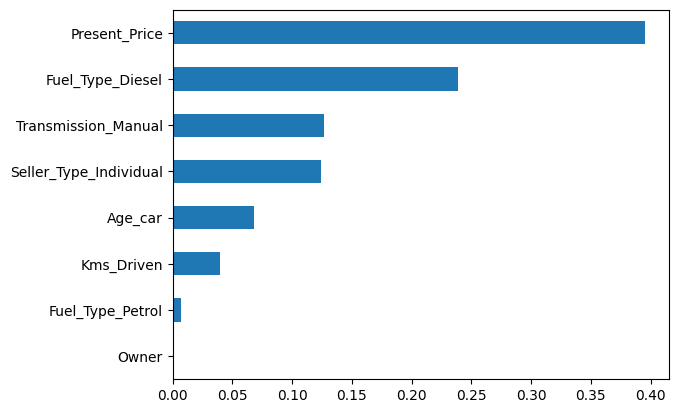

In [204]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')